# 暖冷房負荷モデル 入力再現性スイープ

入力パラメータ（外皮性能・面積）を自動生成し、構築した暖冷房負荷モデルから入力値を
どの程度再現できるかを網羅的に検証する。

- **外皮性能**: `UA` を 0.1〜1.0（0.1刻み）、`ηAC` を 0.5〜5.0（0.5刻み）で格子状に、`ηAH = 1.2·ηAC`。
- **地域**: 1・6・8 地域（寒冷／温暖／蓄熱・冷房主体の対比）。
- **面積**: 集合住宅は1フロア／2フロア（メゾネット）、戸建は平屋／2階建て／3階建てとし、
  ボックス形状から総外皮面積を導出（次節）。室用途別床面積は延床を案分。

本 Notebook はプロジェクト直下（`simple_input.py` 等と `data/` がある場所）で実行する。

## 検証の考え方

### A_env は「振らない」、形状から導く

面積4つ（`A_env`・`A_A`・`A_MR`・`A_OR`）を独立に振るのが難しいのは、`A_env`（総外皮面積）と
`A_A`（延床面積）が建物形状で結ばれているからである。独立サンプリングすると「延床のわりに外皮が
薄すぎ／厚すぎ」という物理的にあり得ない住戸が大量に混ざり、**再現性ではなく入力の不整合**を測ること
になってしまう。

そこで、単純なボックス形状のプリミティブをサンプリングして `A_env` を導出する。これで整合性が自動的に
保証される。

$$F = \frac{A_A}{n}, \qquad
P = 2\sqrt{F}\left(\sqrt{a} + \frac{1}{\sqrt{a}}\right), \qquad
A_{env} = 2F + P\,(n\,h)$$

- $F$：1フロアの床面積（フットプリント）、$n$：階数、$a=W/D$：平面アスペクト比、$h$：階高（床〜床）
- $A_{env}$ ＝ 上面 + 下面 + 側壁（全周 $P$ × 総高さ $n h$）

幾何的には集合住宅と戸建で式は同じで、違うのは階数 $n$・フットプリントと `building_type`
（参照住戸の選択・集合の外気接率ロジスティック・断熱方式）だけ。メゾネットや2・3階建ては $n$ を
変えるだけで表現できる。

### 室用途別床面積の案分

延床 `A_A` を参照住戸比率を中心にジッタを与えて `MR`/`OR` に案分し、残りを `NR` とする
（3室とも >0 を保つよう NR を最低 8% 残す）。

### 何を「再現」とみなすか

各ケースで `verify.verify()` により、最終モデルから `A_A・A_MR・A_OR・A_env・UA・ηA` を逆算し、
入力値との誤差 [%] を求める。許容誤差 0.5% 以内を「再現」とする。

- `UA` は窓補正で U·A が保存されるため、クリップ時でも再現される。
- `A_env`・`ηA` は **窓ηのクリップ（仕様3.4.10）が起きると再現されない**。これがこのスタディの主たる観察対象。

### 窓ηクリップの3つの型（再現が崩れる理由）

窓の垂直入射時日射熱取得率の暫定値
$\eta_{win,temp} = \dfrac{\eta_{A,target}\,A_{env}/100 - m_{wall}}{\sum A_{win}\,\nu}$
を $[0.10,\,0.73]$ にクリップする（$m_{wall}$＝不透明部位の日射取得）。クリップ時の窓面積補正
$A' = \max\!\big(A\cdot \eta_{temp}/\eta_{win},\, 0\big)$ の挙動で、次の3型に分かれる。

| 型 | 条件 | 窓面積補正 | ηA | A_env |
|---|---|---|---|---|
| **下限（緩）** | $0<\eta_{temp}<0.10$ | 縮小（$\eta\cdot A$ 保存）| 再現 | 崩れる |
| **下限（窓0化）** | $\eta_{temp}<0$（高断熱で不透明取得が目標超過）| 0 に潰れる | **再現せず**（不透明取得の床に固定）| 崩れる |
| **上限** | $\eta_{temp}>0.73$ | 拡大（$\eta\cdot A$ 保存）| 再現 | 崩れる |
| **窓なし** | $\sum A_{win}\nu=0$（外気接側に窓が回らない）| — | **再現せず**（同上）| 崩れる |

→ 散布図の `ηA` パネルに見える**水平の赤帯**は「窓0化／窓なし」型。ηA が不透明取得の床に固定され、
目標が高いほど対角線の下に外れる。**上限・下限（緩）型は ηA は対角線上**に乗り、崩れるのは `A_env` 側。

In [1]:
import math, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from matplotlib.lines import Line2D

from simple_input import HeatLoadModel
import verify as vfy

if not os.path.isdir("data"):
    import build_csv  # noqa: F401  （実行時に data/ を書き出す）

# 日本語フォント（環境にあるものを順に試す。無ければ警告のみ）
_jp = ["IPAexGothic", "IPAPGothic", "Noto Sans CJK JP", "Noto Sans JP",
       "Yu Gothic", "Meiryo", "Hiragino Sans", "TakaoPGothic", "VL PGothic"]
_avail = {f.name for f in fm.fontManager.ttflist}
_use = next((f for f in _jp if f in _avail), None)
if _use:
    plt.rcParams["font.family"] = _use
else:
    print("※ 日本語フォントが見つかりません。図中の日本語が□になる場合があります。")
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

In [2]:
# ---- 建て方・階数の構成 -----------------------------------------------------
# name, building_type, n_floors, A_A範囲[m2], is_floor_ins の振り方
CONFIGS = [
    ("集合_フラット",   "apartment", 1, (40,  100), [True]),
    ("集合_メゾネット", "apartment", 2, (60,  130), [True]),
    ("戸建_平屋",       "detached",  1, (50,  100), [True, False]),
    ("戸建_2階建",      "detached",  2, (90,  140), [True, False]),
    ("戸建_3階建",      "detached",  3, (120, 180), [True, False]),
]
ALLOC = {
    "apartment": dict(mr=(0.30, 0.40), orr=(0.35, 0.48)),
    "detached":  dict(mr=(0.20, 0.32), orr=(0.38, 0.50)),
}
ASPECT = (1.0, 2.0)   # 平面アスペクト比 W/D
HEIGHT = (2.7, 2.9)   # 階高（床〜床）[m]


def box_envelope(A_A, n, aspect, h):
    """ボックス形状から総外皮面積 A_env を導出する。"""
    F = A_A / n
    P = 2.0 * math.sqrt(F) * (math.sqrt(aspect) + 1.0 / math.sqrt(aspect))
    return 2.0 * F + P * (n * h)


def allocate(A_A, bt, rng):
    """延床面積を MR/OR に案分（NR=残り、3室とも>0）。"""
    lo_mr, hi_mr = ALLOC[bt]["mr"]
    lo_or, hi_or = ALLOC[bt]["orr"]
    f_mr = rng.uniform(lo_mr, hi_mr)
    f_or = rng.uniform(lo_or, hi_or)
    if f_mr + f_or > 0.92:
        s = 0.92 / (f_mr + f_or)
        f_mr, f_or = f_mr * s, f_or * s
    return round(A_A * f_mr, 2), round(A_A * f_or, 2)


def generate_cases(ua_list, etac_list, regions, n_geom=5, seed=0):
    """全構成 × 形状サンプル × (UA×ηAC×region) の入力ケースを生成。"""
    rng = random.Random(seed)
    cases = []
    for cname, bt, n, (a_lo, a_hi), floor_ins_list in CONFIGS:
        for _g in range(n_geom):
            A_A = round(rng.uniform(a_lo, a_hi), 2)
            aspect = rng.uniform(*ASPECT)
            h = rng.uniform(*HEIGHT)
            A_env = round(box_envelope(A_A, n, aspect, h), 2)
            A_MR, A_OR = allocate(A_A, bt, rng)
            for fins in floor_ins_list:
                for region in regions:
                    for UA in ua_list:
                        for etac in etac_list:
                            cases.append(dict(
                                config=cname, building_type=bt, n_floors=n,
                                is_floor_ins=fins, region=region,
                                A_A=A_A, A_env=A_env, A_MR=A_MR, A_OR=A_OR,
                                aspect=round(aspect, 3), h=round(h, 3),
                                UA=round(UA, 2), eta_AC=round(etac, 2),
                                eta_AH=round(1.2 * etac, 3)))
    return cases


def clip_kind(et, clipped):
    """窓ηクリップの型を分類する（et=eta_win_temp）。"""
    if not clipped:
        return "なし"
    if et is None or (isinstance(et, float) and math.isnan(et)):
        return "窓なし(不透明のみ)"
    if et < 0:
        return "下限・窓0化(et<0)"
    if et < 0.10:
        return "下限(0<et<0.10)"
    if et > 0.73:
        return "上限(et>0.73)"
    return "なし"

In [3]:
def run(cases, tol=0.5):
    """各ケースを構築・検証し、再現誤差・窓クリップ型を集計して DataFrame で返す。"""
    rows = []
    for cc in cases:
        try:
            m = HeatLoadModel(
                building_type=cc["building_type"], A_MR=cc["A_MR"], A_OR=cc["A_OR"],
                A_A=cc["A_A"], region=cc["region"], A_env=cc["A_env"], UA=cc["UA"],
                eta_AC=cc["eta_AC"], eta_AH=cc["eta_AH"], is_floor_ins=cc["is_floor_ins"])
            r = vfy.verify(m, tol=tol)
            et = r["_eta_win_temp"]
            rows.append({**cc,
                         "bt_jp": "集合" if cc["building_type"] == "apartment" else "戸建",
                         "A_env_model": r["A_env"]["model"],
                         "UA_model":    r["UA"]["model"],
                         "etaA_target": r["etaA"]["target"],
                         "etaA_model":  r["etaA"]["model"],
                         "err_A_env": r["A_env"]["err_pct"],
                         "err_UA":    r["UA"]["err_pct"],
                         "err_etaA":  r["etaA"]["err_pct"],
                         "clipped":   bool(r["_window_clipped"]),
                         "clip_kind": clip_kind(et, bool(r["_window_clipped"])),
                         "eta_win_temp": et,
                         "eta_win":   r["_eta_win"],
                         "ok": all(r[k]["ok"] for k in
                                   ("A_A","A_MR","A_OR","A_env","UA","etaA")),
                         "error": ""})
        except Exception as e:
            rows.append({**cc, "bt_jp": "集合" if cc["building_type"]=="apartment" else "戸建",
                         "ok": False, "clipped": None, "clip_kind": "エラー", "error": str(e)})
    return pd.DataFrame(rows)


UA_LIST   = [round(0.1*i, 1) for i in range(1, 11)]   # 0.1〜1.0
ETAC_LIST = [round(0.5*i, 1) for i in range(1, 11)]   # 0.5〜5.0
REGIONS   = [1, 6, 8]                                  # 寒冷 / 温暖 / 冷房主体

cases = generate_cases(UA_LIST, ETAC_LIST, REGIONS, n_geom=5, seed=1)
df = run(cases, tol=0.5)
os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/repro_sweep.csv", index=False, encoding="utf-8-sig")
print(f"総ケース数: {len(df)}  地域: {REGIONS}  → outputs/repro_sweep.csv")
df.head()

総ケース数: 12000  地域: [1, 6, 8]  → outputs/repro_sweep.csv


,config,building_type,n_floors,is_floor_ins,region,A_A,A_env,A_MR,A_OR,aspect,...,etaA_model,err_A_env,err_UA,err_etaA,clipped,clip_kind,eta_win_temp,eta_win,ok,error
0,集合_フラット,apartment,1,True,1,48.06,178.98,15.64,19.92,1.847,...,0.185396,-1.587982e-14,0.0,-68.194452,True,窓なし(不透明のみ),NaN,0.1,False,
1,集合_フラット,apartment,1,True,1,48.06,178.98,15.64,19.92,1.847,...,0.185396,-1.587982e-14,0.0,-84.097226,True,窓なし(不透明のみ),NaN,0.1,False,
2,集合_フラット,apartment,1,True,1,48.06,178.98,15.64,19.92,1.847,...,0.185396,-1.587982e-14,0.0,-89.398151,True,窓なし(不透明のみ),NaN,0.1,False,
3,集合_フラット,apartment,1,True,1,48.06,178.98,15.64,19.92,1.847,...,0.185396,-1.587982e-14,0.0,-92.048613,True,窓なし(不透明のみ),NaN,0.1,False,
4,集合_フラット,apartment,1,True,1,48.06,178.98,15.64,19.92,1.847,...,0.185396,-1.587982e-14,0.0,-93.638890,True,窓なし(不透明のみ),NaN,0.1,False,


## 集計

In [4]:
def pct(s):
    return round(100.0 * s.mean(), 1)

print("【全体】")
print(pd.Series({"再現率%": pct(df["ok"]),
                 "クリップ%": pct(df["clipped"] == True),
                 "エラー%": pct(df["error"] != "")}).to_string())

print("\n【構成別】")
g = df.groupby("config", sort=False).apply(lambda d: pd.Series({
    "件数": len(d), "再現率%": pct(d["ok"]),
    "クリップ%": pct(d["clipped"] == True)}), include_groups=False)
print(g.to_string())

print("\n【地域別 × 構成別 再現率%】")
piv = df.pivot_table(index="config", columns="region", values="ok",
                     aggfunc="mean", sort=False) * 100
print(piv.round(1).to_string())

【全体】
再現率%     63.1
クリップ%    37.5
エラー%      0.0

【構成別】
              件数  再現率%  クリップ%
config                       
集合_フラット   1500.0   2.9   98.1
集合_メゾネット  1500.0   2.9   97.5
戸建_平屋     3000.0  82.8   17.9
戸建_2階建    3000.0  83.2   17.3
戸建_3階建    3000.0  83.6   16.8

【地域別 × 構成別 再現率%】
region       1     6     8
config                    
集合_フラット    3.2   3.2   2.2
集合_メゾネット   3.4   3.0   2.2
戸建_平屋     82.4  84.0  81.9
戸建_2階建    82.9  84.5  82.3
戸建_3階建    83.4  84.7  82.6


## クリップ方向の内訳（戸建 vs 集合）

「戸建は下限／集合は上限」なのかを実データで確認する。建て方別にクリップの型を数える。

In [5]:
tab = (df[df["clipped"] == True]
       .pivot_table(index="clip_kind", columns="bt_jp", values="config",
                    aggfunc="count", fill_value=0))
# ηA 再現率も型別に
rep = (df[df["clipped"] == True]
       .pivot_table(index="clip_kind", columns="bt_jp", values="ok",
                    aggfunc="mean", fill_value=np.nan) * 100).round(0)
print("【クリップ型 × 建て方：件数】")
print(tab.to_string())
print("\n【クリップ型 × 建て方：全項目再現率%（A_envも含むため上限/下限緩でも低い）】")
print(rep.to_string())

【クリップ型 × 建て方：件数】
bt_jp            戸建    集合
clip_kind                
上限(et>0.73)       0   486
下限(0<et<0.10)  1231     6
下限・窓0化(et<0)    329   133
窓なし(不透明のみ)        0  2310

【クリップ型 × 建て方：全項目再現率%（A_envも含むため上限/下限緩でも低い）】
bt_jp           戸建    集合
clip_kind               
上限(et>0.73)    NaN   4.0
下限(0<et<0.10)  4.0  17.0
下限・窓0化(et<0)   0.0   0.0
窓なし(不透明のみ)     NaN   0.0


## 入力データの再現性 散布図（戸建 / 集合に分割）

横軸に**入力値**、縦軸に**モデル再現値**。対角線 $y=x$ に乗れば再現できている。
窓ηクリップ発生を色分けし、**戸建と集合で別図**にする。

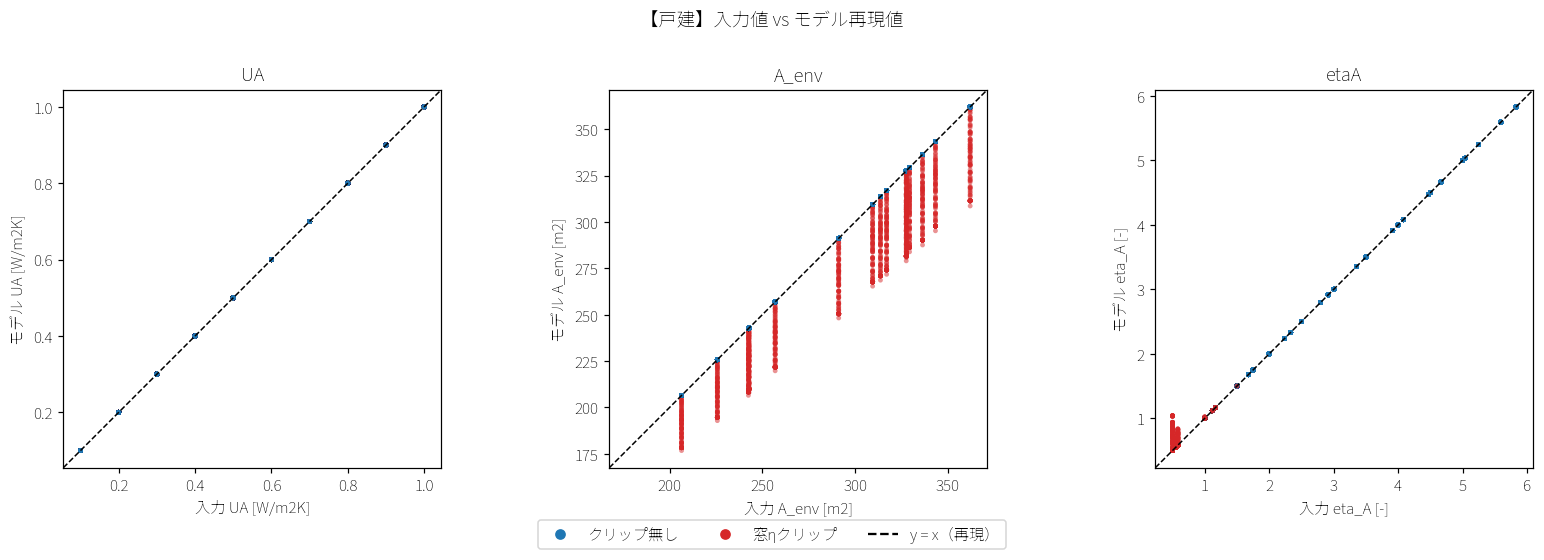

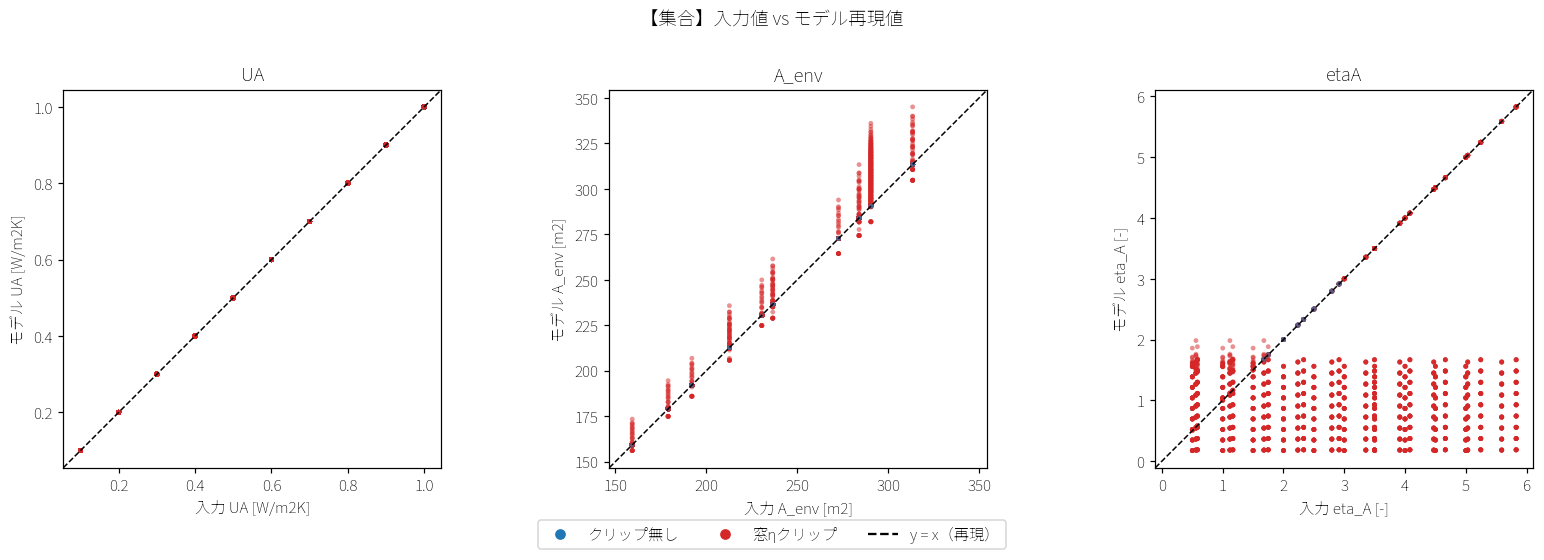

In [6]:
def plot_repro(dsub, title):
    col = np.where(dsub["clipped"], "#d62728", "#1f77b4")  # クリップ=赤, 非=青
    panels = [
        ("UA",   dsub["UA"],          dsub["UA_model"],    "UA [W/m2K]"),
        ("A_env",dsub["A_env"],       dsub["A_env_model"], "A_env [m2]"),
        ("etaA", dsub["etaA_target"], dsub["etaA_model"],  "eta_A [-]"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    for ax, (key, x, y, label) in zip(axes, panels):
        ax.scatter(x, y, s=10, c=col, alpha=0.5, edgecolors="none")
        lo = float(min(x.min(), y.min())); hi = float(max(x.max(), y.max()))
        pad = (hi - lo) * 0.05 or 0.1
        ax.plot([lo-pad, hi+pad], [lo-pad, hi+pad], "k--", lw=1)
        ax.set_xlim(lo-pad, hi+pad); ax.set_ylim(lo-pad, hi+pad)
        ax.set_xlabel(f"入力 {label}"); ax.set_ylabel(f"モデル {label}")
        ax.set_title(key); ax.set_aspect("equal", "box")
    handles = [Line2D([],[],marker="o",ls="",c="#1f77b4",label="クリップ無し"),
               Line2D([],[],marker="o",ls="",c="#d62728",label="窓ηクリップ"),
               Line2D([],[],ls="--",c="k",label="y = x（再現）")]
    fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.06))
    fig.suptitle(title, y=1.02)
    plt.tight_layout(); plt.show()

plot_repro(df[(df["bt_jp"]=="戸建") & (df["error"]=="")], "【戸建】入力値 vs モデル再現値")
plot_repro(df[(df["bt_jp"]=="集合") & (df["error"]=="")], "【集合】入力値 vs モデル再現値")

## どこでクリップが起きるか（UA–ηAC 平面・戸建/集合別）

クリップ型を色分けして UA–ηAC 平面に描く（地域はプール）。戸建は下限側、集合は上限・窓なしが
出やすいことを確認する。

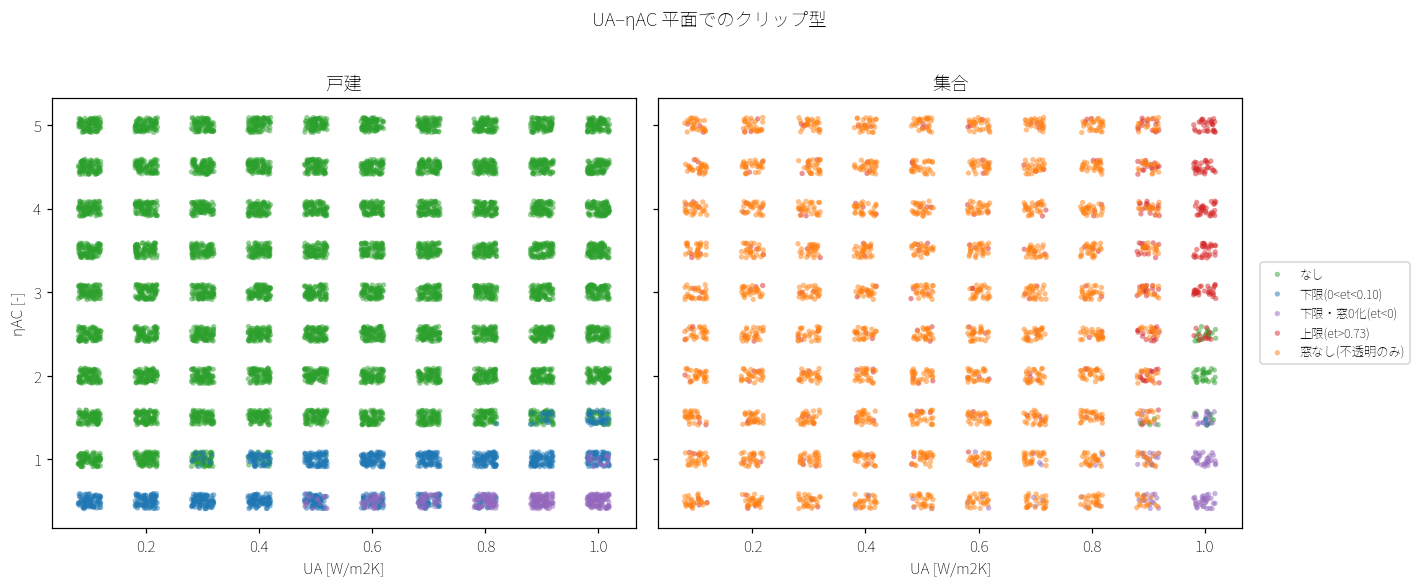

In [7]:
KIND_COLOR = {
    "なし":              "#2ca02c",
    "下限(0<et<0.10)":   "#1f77b4",
    "下限・窓0化(et<0)": "#9467bd",
    "上限(et>0.73)":     "#d62728",
    "窓なし(不透明のみ)": "#ff7f0e",
}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True, sharey=True)
for ax, bt in zip(axes, ["戸建", "集合"]):
    dd = df[(df["bt_jp"] == bt) & (df["error"] == "")]
    for kind, cc in KIND_COLOR.items():
        sub = dd[dd["clip_kind"] == kind]
        if len(sub):
            # 同一(UA,ηAC)に複数地域・構成が重なるので軽くジッタ
            jx = (np.random.RandomState(0).rand(len(sub)) - 0.5) * 0.04
            jy = (np.random.RandomState(1).rand(len(sub)) - 0.5) * 0.18
            ax.scatter(sub["UA"] + jx, sub["eta_AC"] + jy, s=12, alpha=0.5,
                       color=cc, edgecolors="none", label=kind)
    ax.set_title(bt); ax.set_xlabel("UA [W/m2K]")
axes[0].set_ylabel("ηAC [-]")
axes[1].legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.suptitle("UA–ηAC 平面でのクリップ型", y=1.02)
plt.tight_layout(); plt.show()

## 所見・留意点

- **戸建のクリップはすべて下限側**（$\eta_{temp}<0.10$）で、上限は出ない。多くは下限（緩）型で ηA は
  再現され、`A_env` のみ崩れる。ごく一部、高断熱・低 ηA で $\eta_{temp}<0$ となり窓が 0 に潰れ、
  ηA が不透明取得の床に固定されて再現できない。
- **集合は型が混在**する。上限クリップ（$\eta_{temp}>0.73$）は確かに存在し ηA は再現されるが、
  最大の再現失敗要因は**外気接側に窓が回らず $\sum A_{win}\nu=0$ となる「窓なし」型**。このとき ηA は
  不透明取得の床に固定され、目標が高いほど対角線の下に外れる（散布図の水平な赤帯）。
- 集合の窓なし型が多いのは、参照集合住戸の窓が南北面中心で、外気接率が下がる低 UA 域では外気接側に
  窓が割り当たりにくいため。集合の `A_env` はボックス全6面を外皮として与えており、中間階・中間住戸では
  界面はさらに多い。クリップ率はむしろ過小評価寄りである点に留意。
- 地域は 1・6・8。8地域は暖房日数0で方位係数・ηA目標が冷房側に寄るため、クリップ発生の地域差が出る
  （地域別×構成別の再現率表を参照）。
- `ηAH = 1.2·ηAC` は (ηAC, ηAH) 平面の1次元スライス。倍率を複数にすると面で評価できる。
- 床面積0で室が減る縮退ケースは別途 `test_room_count.py` でカバー済み。本スイープは3室を保持した
  標準ケースに絞っている。